# Churn Analysis - Exploratory Data Analysis

**Dataset Info:**
Sample dataset containing customer data showing customers who left last month from a telecom company.
The target variable is `Churn` (Yes/No) indicating whether the customer left the company.

**Goal of EDA:**
- Understand the structure and distribution of the data
- Identify missing values and data quality issues
- Explore relationships between features and the target (Churn)
- Derive actionable insights before building models

## 1. Import Required Libraries

`numpy` and `pandas` are the core libraries for numerical operations and data manipulation.
`seaborn` and `matplotlib` are used for visualization.
`mtick` provides custom tick formatting for axes.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt

# Inline plots
%matplotlib inline

## 2. Load the Dataset

We use `pd.read_csv` to load the CSV file.
The path is constructed dynamically using `os.path` so this notebook works regardless of where the project is cloned.

Other common loaders:
- Excel files: `pd.read_excel`
- Text files with custom separator: `pd.read_csv(..., sep=';')`

In [3]:
import os

# Resolve the data path relative to this notebook's location
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join(NOTEBOOK_DIR, 'data', 'Customer-Churn.csv')

df = pd.read_csv(DATA_PATH)
print("Type of loaded object:", type(df))
print("Data loaded successfully")

Type of loaded object: <class 'pandas.DataFrame'>
Data loaded successfully


## 3. Initial Data Inspection

We inspect the first few rows, shape, column names, and data types to understand what we are working with.

In [4]:
# Top 5 records
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Dimensions: (rows, columns)
df.shape

(7043, 21)

In [6]:
# All column names
df.columns.values

<ArrowStringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

In [7]:
# Data types of each column
# Note: TotalCharges should be numeric but is read as object (string) due to whitespace entries
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
# Descriptive statistics for numeric columns
# Note: SeniorCitizen (0/1) is numeric here but is actually categorical
# Key observation: 75% of customers have tenure < 55 months
# Average MonthlyCharges = $64.76 but 25% pay more than $89.85
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 4. Explore the Target Variable (Churn)

Understanding class distribution is critical before any modelling.
An imbalanced target variable requires special handling during model training.

In [9]:
# Raw counts
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
# Percentage breakdown
# Result: ~73% No, ~27% Yes -> imbalanced dataset
df['Churn'].value_counts() / len(df) * 100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

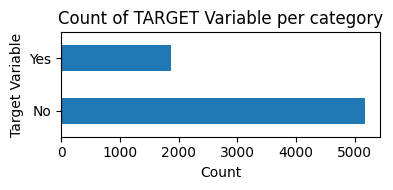

In [11]:
# Horizontal bar chart for clarity
df['Churn'].value_counts().plot(kind='barh', figsize=(4, 2))
plt.xlabel('Count')
plt.ylabel('Target Variable')
plt.title('Count of TARGET Variable per category')
plt.tight_layout()
plt.show()

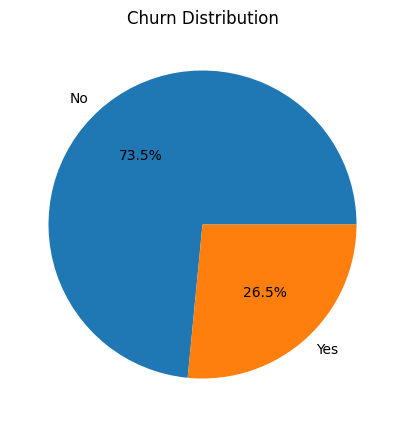

In [13]:
# Pie chart
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5, 5))
plt.title('Churn Distribution')
plt.ylabel('')
plt.show()


Key Insight: Data is highly imbalanced - ratio ~ 73:27
We must handle this imbalance during model training using techniques like SMOTE, SMOTEENN, or class weighting.

## 5. Missing Value Analysis

We use `df.info()` for a concise summary including non-null counts.
Then we check for null values and visualize their percentage.

In [14]:
# Concise summary: shows dtype, non-null count for each column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [15]:
# Count of null values per column
# At this stage: 0 nulls because TotalCharges is still a string (whitespace reads as non-null)
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

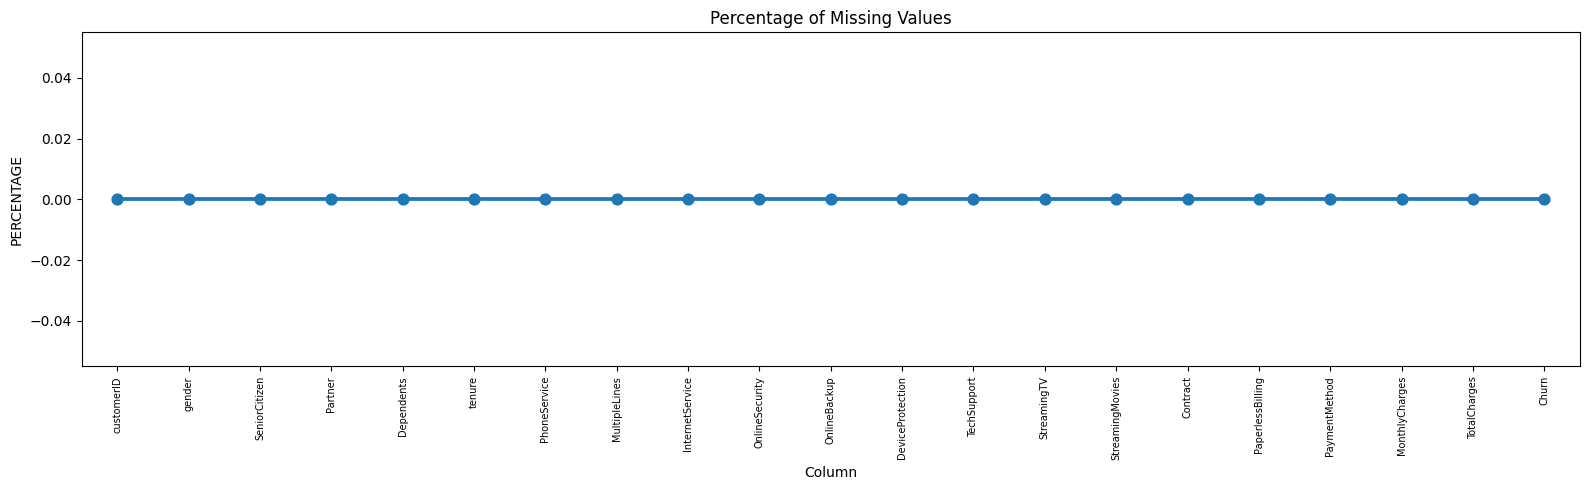

In [17]:
# Visualize percentage of missing values
missing = pd.DataFrame((df.isnull().sum()) * 100 / df.shape[0]).reset_index()
missing.columns = ['Column', 'Missing_Percentage']
plt.figure(figsize=(16, 5))
ax = sns.pointplot(x='Column', y='Missing_Percentage', data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title('Percentage of Missing Values')
plt.ylabel('PERCENTAGE')
plt.tight_layout()
plt.show()

Initial Finding: No missing values visible yet.
TotalCharges has whitespace entries which appear non-null but will become NaN when we convert to numeric (next step).

## 6. Data Cleaning

### Step 1: Create a working copy
Always work on a copy of the original dataframe to preserve the raw data.

In [18]:
new_df = df.copy()

### Step 2: Fix TotalCharges dtype

`TotalCharges` was loaded as a string because some entries contain only whitespace.
`errors='coerce'` converts those invalid entries to `NaN` instead of raising an error.

In [19]:
new_df.TotalCharges = pd.to_numeric(new_df.TotalCharges, errors='coerce')
print("TotalCharges dtype after conversion:", new_df.TotalCharges.dtype)

TotalCharges dtype after conversion: float64


In [20]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [21]:
# Now NaN values appear for the whitespace entries
new_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

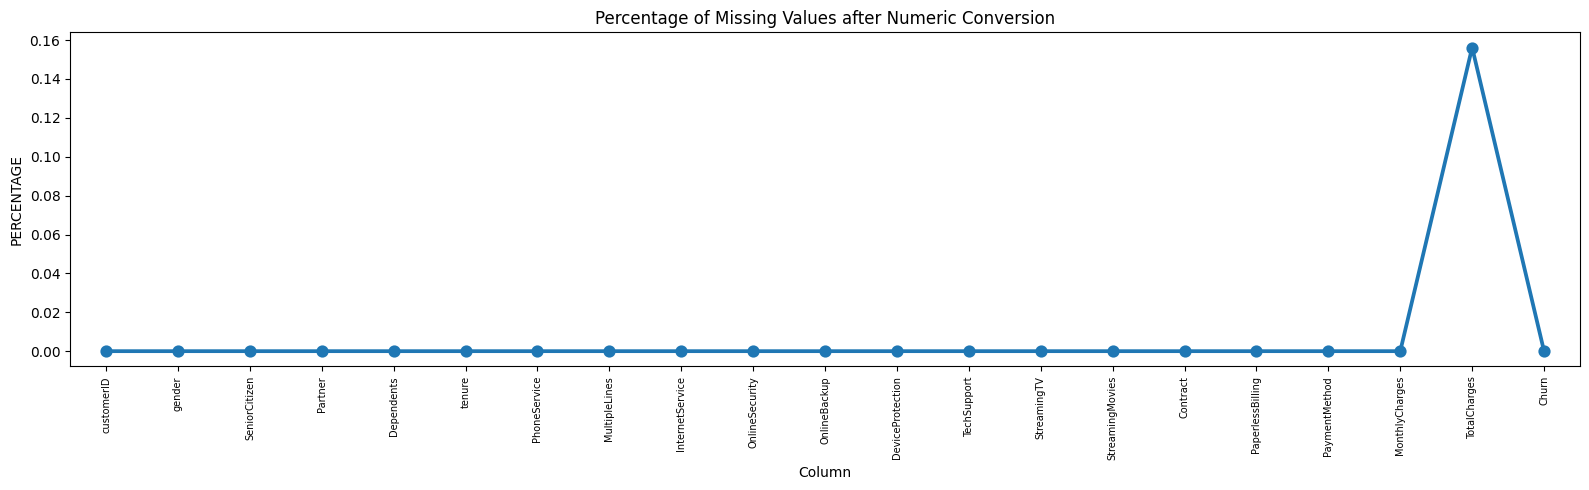

In [22]:
# Visualize missing values after coerce
missing = pd.DataFrame((new_df.isnull().sum()) * 100 / new_df.shape[0]).reset_index()
missing.columns = ['Column', 'Missing_Percentage']
plt.figure(figsize=(16, 5))
sns.pointplot(x='Column', y='Missing_Percentage', data=missing)
plt.xticks(rotation=90, fontsize=7)
plt.title('Percentage of Missing Values after Numeric Conversion')
plt.ylabel('PERCENTAGE')
plt.tight_layout()
plt.show()

### Step 3: Inspect the missing rows

We check which rows have NaN in TotalCharges to decide how to handle them.

In [23]:
# These 11 rows have tenure=0, meaning new customers with no charges yet
new_df.loc[new_df['TotalCharges'].isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


### Step 4: Remove missing rows

The 11 missing rows represent only 0.15% of the 7043 records.
This is negligible - dropping them is safe and will not affect model performance.

General thumb rules for missing data:
- Less than 5% missing: safe to drop or impute with mean/regression
- More than 30-40% missing: consider dropping the column entirely
- Always consider domain context before dropping (e.g., Car_Type=NaN might mean no car)

In [24]:
new_df.dropna(how='any', inplace=True)
print("Shape after removing missing values:", new_df.shape)
# Expected: (7032, 21) - 11 rows removed

Shape after removing missing values: (7032, 21)


### Step 5: Create Tenure Bins

Grouping continuous tenure (months) into 12-month intervals makes the feature
more interpretable and handles non-linear relationships with churn.

Example:
- 1-12 months: new customers
- 61-72 months: long-term loyal customers

In [25]:
# Max tenure in dataset
print("Max tenure:", new_df['tenure'].max())  # Should be 72

Max tenure: 72


In [26]:
# Generate bin labels: '1 - 12', '13 - 24', ..., '61 - 72'
labels = ["{0} - {1}".format(i, i + 11) for i in range(1, 72, 12)]
print("Labels:", labels)

Labels: ['1 - 12', '13 - 24', '25 - 36', '37 - 48', '49 - 60', '61 - 72']


In [27]:
# pd.cut divides tenure into equal-width bins
# right=False means left-inclusive: [1,13), [13,25), ...
new_df['tenure_group'] = pd.cut(new_df.tenure, range(1, 80, 12), right=False, labels=labels)
print(new_df['tenure_group'].value_counts())

tenure_group
1 - 12     2175
61 - 72    1407
13 - 24    1024
25 - 36     832
49 - 60     832
37 - 48     762
Name: count, dtype: int64


### Step 6: Drop columns not needed for EDA

`customerID` is a unique identifier with no predictive value.
`tenure` is now represented by `tenure_group` so the raw column is dropped.

In [28]:
new_df.drop(columns=['customerID', 'tenure'], inplace=True)
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12


## 7. Univariate Analysis

We examine each feature individually, broken down by the Churn target variable.

In [29]:
# Churn rate after cleaning
new_df.Churn.value_counts() / len(new_df) * 100

Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64

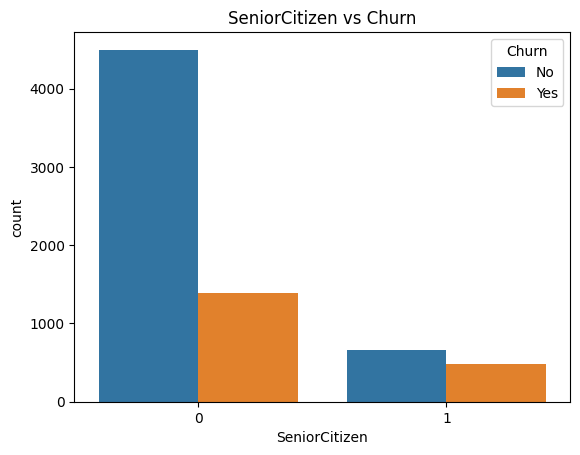

In [30]:
# SeniorCitizen breakdown by Churn
# Even though SeniorCitizen is numeric (0/1), it is categorical
sns.countplot(data=new_df, x='SeniorCitizen', hue='Churn')
plt.title('SeniorCitizen vs Churn')
plt.show()

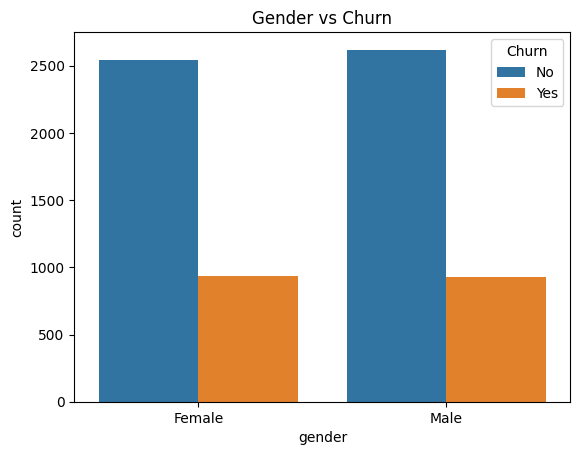

In [31]:
# Gender breakdown by Churn - should show minimal difference
sns.countplot(data=new_df, x='gender', hue='Churn')
plt.title('Gender vs Churn')
plt.show()

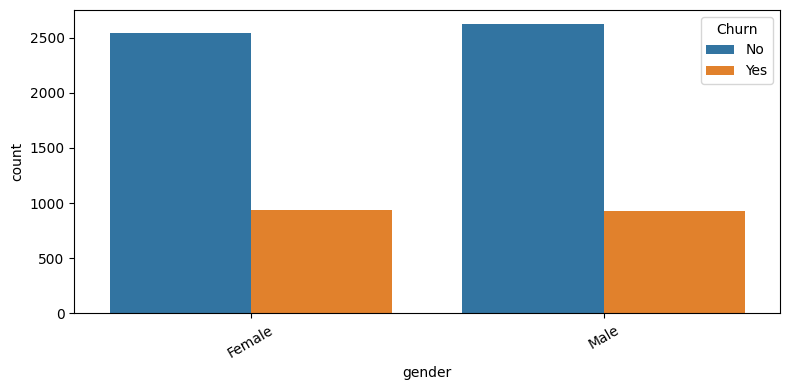

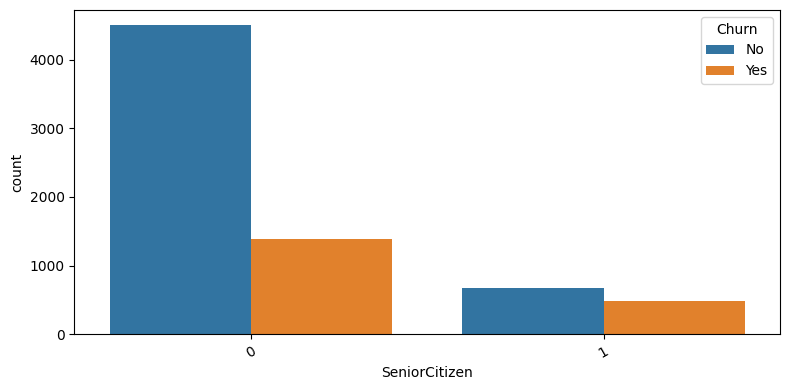

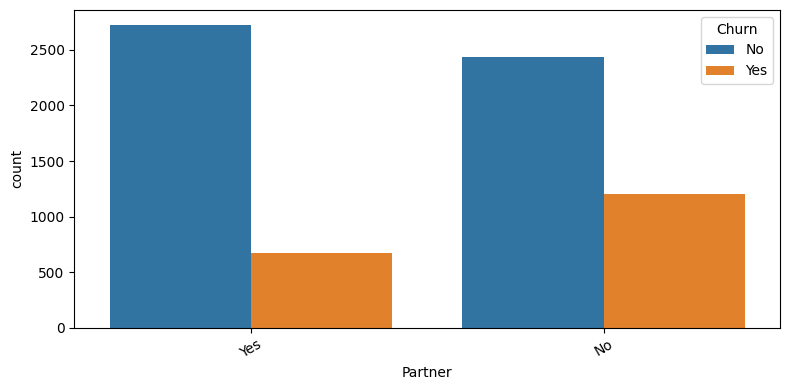

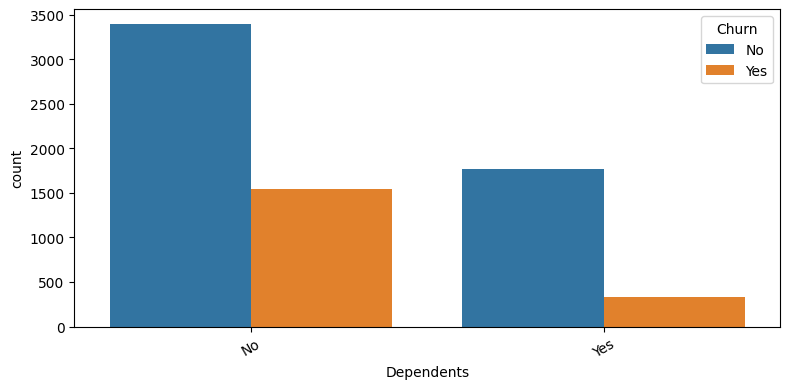

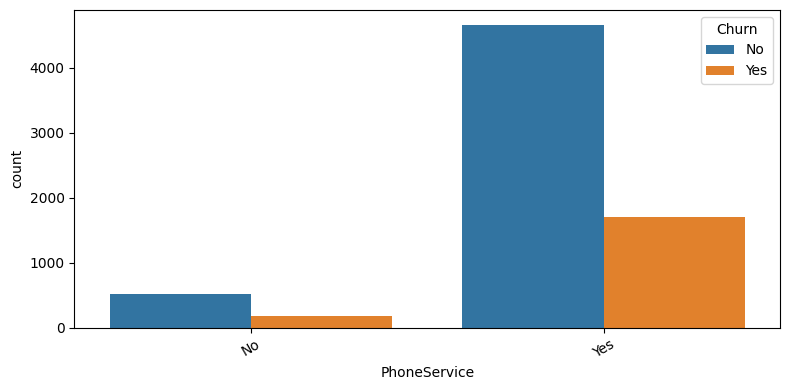

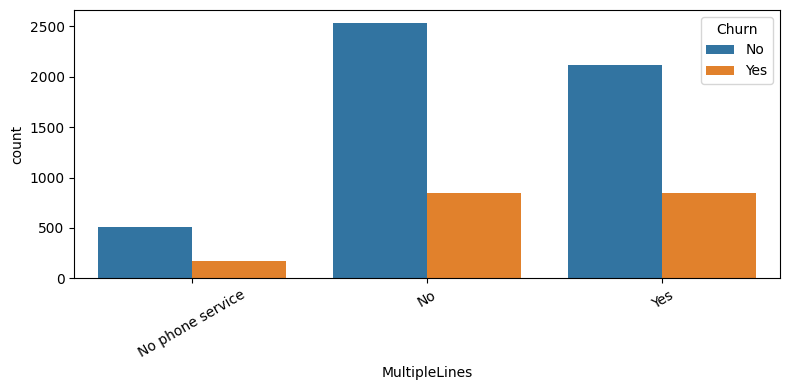

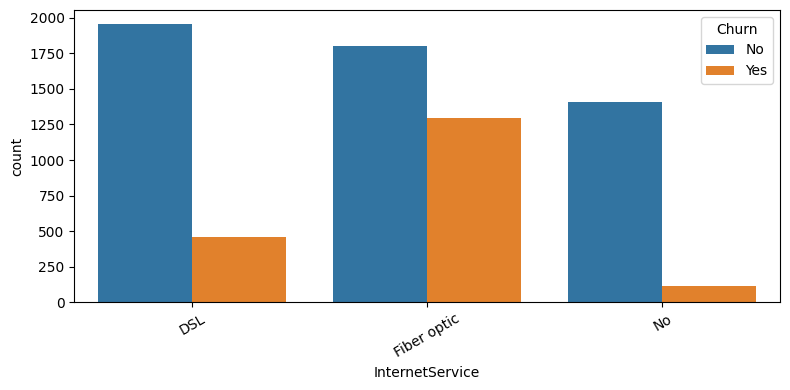

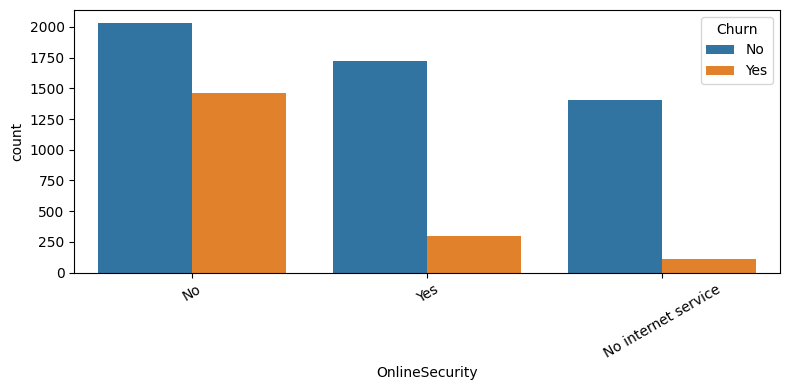

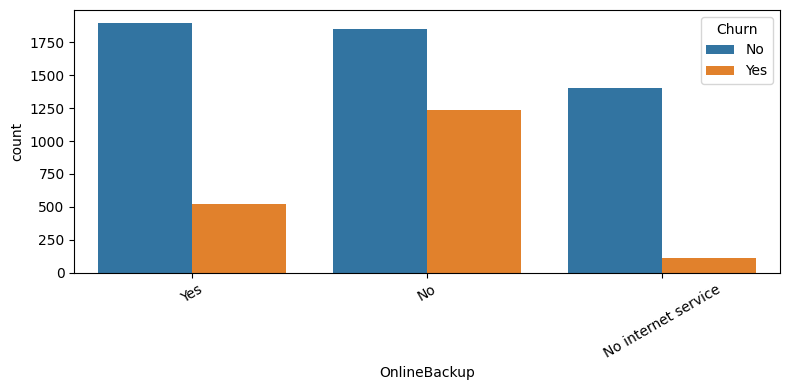

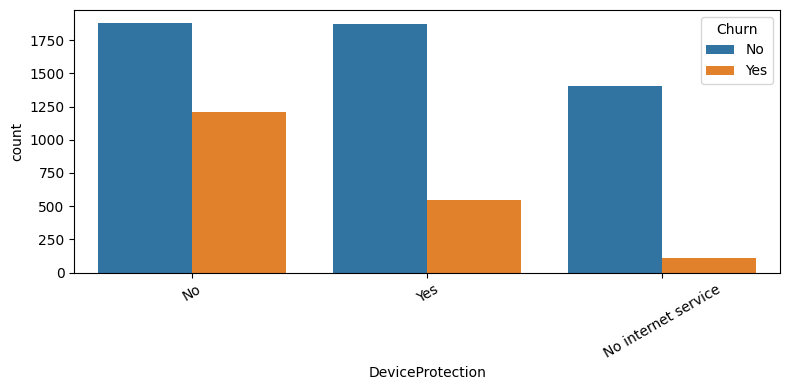

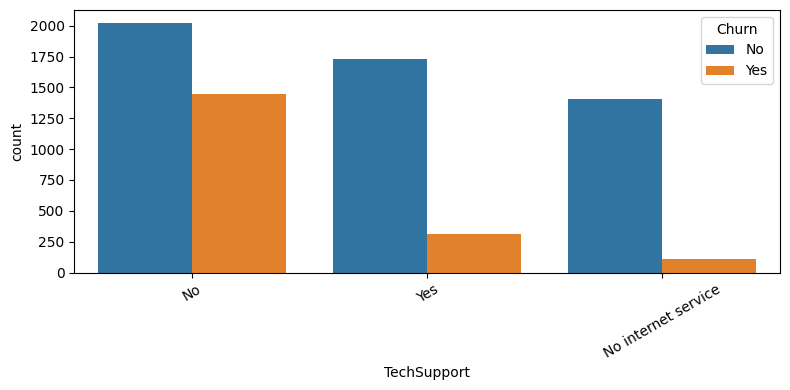

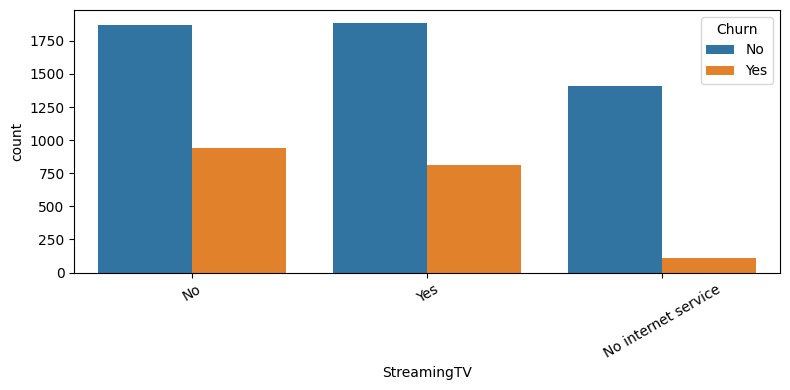

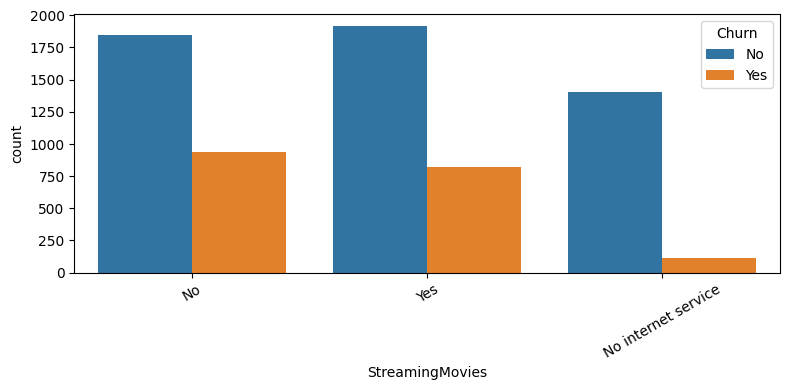

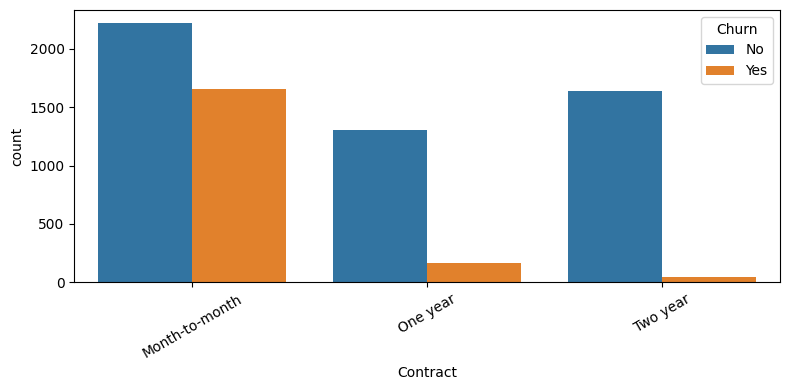

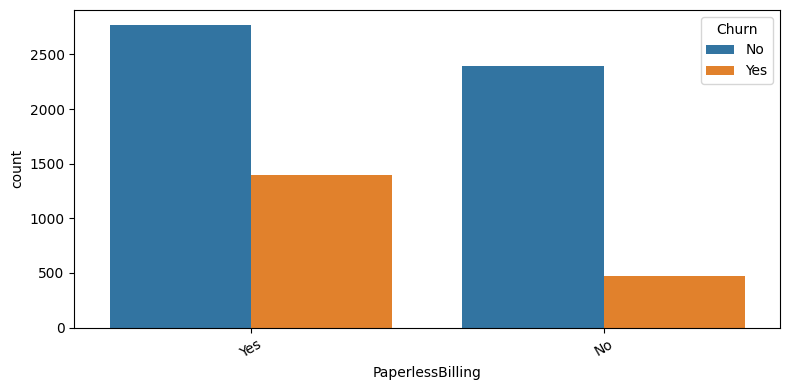

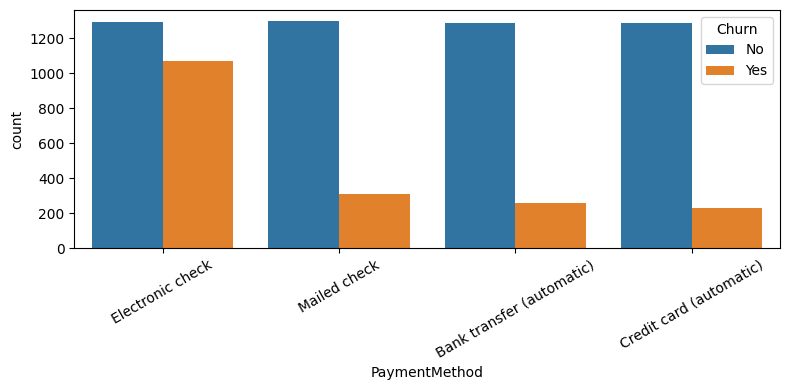

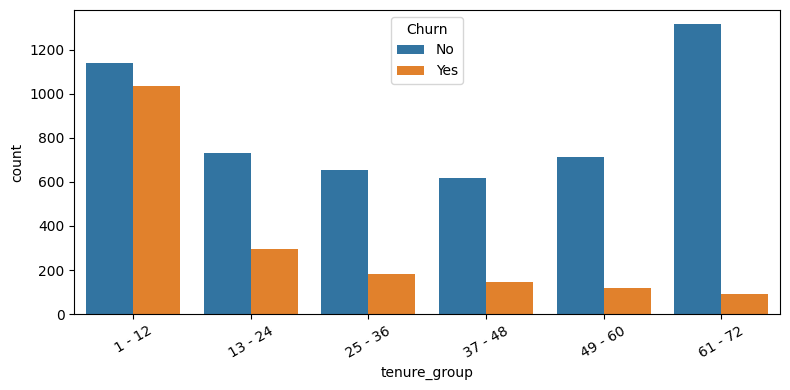

In [32]:
# Plot all categorical features (excluding numeric and target)
# This loop produces one chart per categorical predictor
for i, predictor in enumerate(new_df.drop(columns=['Churn', 'TotalCharges', 'MonthlyCharges'])):
    plt.figure(i, figsize=(8, 4))
    sns.countplot(data=new_df, x=predictor, hue='Churn')
    plt.xticks(rotation=30)
    plt.tight_layout()
plt.show()

In [33]:
# PaymentMethod cross-tabulation with Churn
pd.crosstab(new_df.PaymentMethod, new_df.Churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


## 8. Convert Churn to Numeric and Encode Features

Machine learning models require numeric input.
- `np.where` converts Yes/No to 1/0 for the Churn column
- `pd.get_dummies` performs one-hot encoding on all remaining categorical columns

In [34]:
new_df['Churn'] = np.where(new_df.Churn == 'Yes', 1, 0)
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1 - 12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


In [35]:
new_df_dummies = pd.get_dummies(new_df)
new_df_dummies.head()

,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29.85,29.85,0,True,False,False,True,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,56.95,1889.50,0,False,True,True,False,True,False,...,False,False,False,True,False,False,True,False,False,False
2,0,53.85,108.15,1,False,True,True,False,True,False,...,False,False,False,True,True,False,False,False,False,False
3,0,42.30,1840.75,0,False,True,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,70.70,151.65,1,True,False,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False


## 9. Relationship: Monthly Charges vs Total Charges

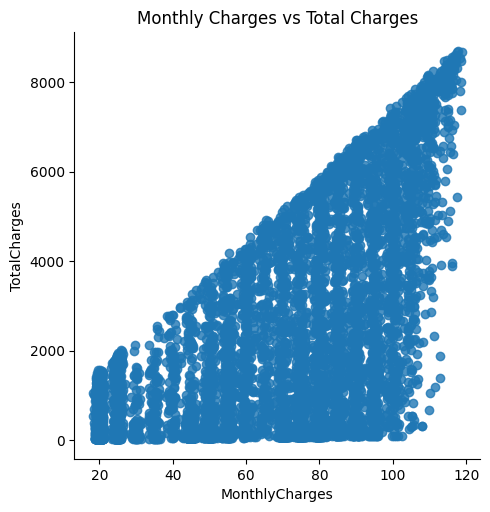

In [36]:
# Scatter plot - expected: positive relationship
sns.lmplot(data=new_df_dummies, x='MonthlyCharges', y='TotalCharges', fit_reg=False)
plt.title('Monthly Charges vs Total Charges')
plt.show()

In [37]:
# Correlation between the two charge columns
corr_val = new_df_dummies['MonthlyCharges'].corr(new_df_dummies['TotalCharges'])
print(f"Correlation between MonthlyCharges and TotalCharges: {corr_val:.4f}")
# High positive correlation - as expected, total increases with monthly charges

Correlation between MonthlyCharges and TotalCharges: 0.6511


## 10. Churn by Monthly Charges and Total Charges (KDE Plots)

KDE (Kernel Density Estimation) plots show the probability distribution of a continuous variable,
separated by the two Churn groups.

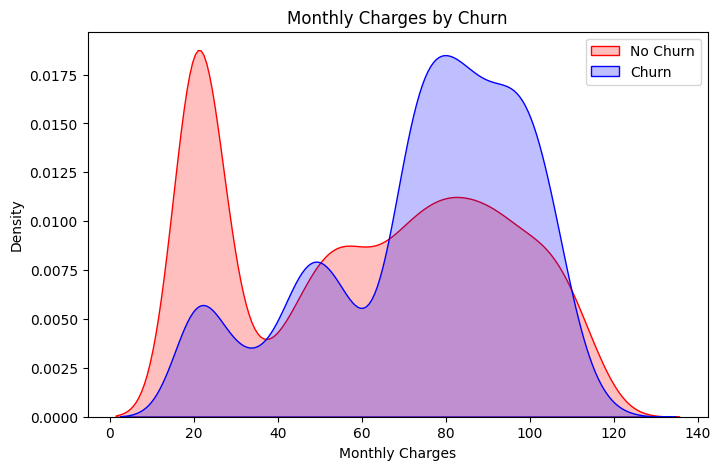

In [39]:
# Higher monthly charges are associated with more churn
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(new_df_dummies.MonthlyCharges[new_df_dummies['Churn'] == 0],
            color='Red', fill=True, label='No Churn', ax=ax)
sns.kdeplot(new_df_dummies.MonthlyCharges[new_df_dummies['Churn'] == 1],
            color='Blue', fill=True, label='Churn', ax=ax)
ax.legend(loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Monthly Charges')
ax.set_title('Monthly Charges by Churn')
plt.show()

Insight: Churn is higher when Monthly Charges are high

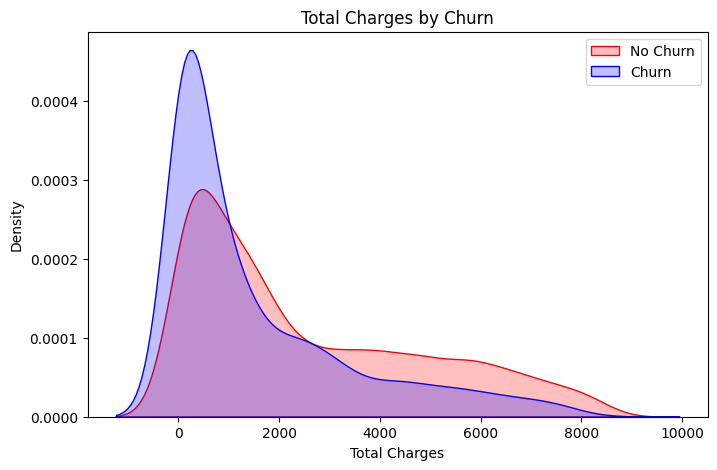

In [41]:
# Lower total charges are associated with more churn (new customers)
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(new_df_dummies.TotalCharges[new_df_dummies['Churn'] == 0],
            color='Red', fill=True, label='No Churn', ax=ax)
sns.kdeplot(new_df_dummies.TotalCharges[new_df_dummies['Churn'] == 1],
            color='Blue', fill=True, label='Churn', ax=ax)
ax.legend(loc='upper right')
ax.set_ylabel('Density')
ax.set_xlabel('Total Charges')
ax.set_title('Total Charges by Churn')
plt.show()


Insight: Higher churn at lower Total Charges.
Combined with the tenure insight: new customers (low tenure) pay high monthly charges but have low total charges - these are the highest churners.


## 11. Correlation of All Predictors with Churn

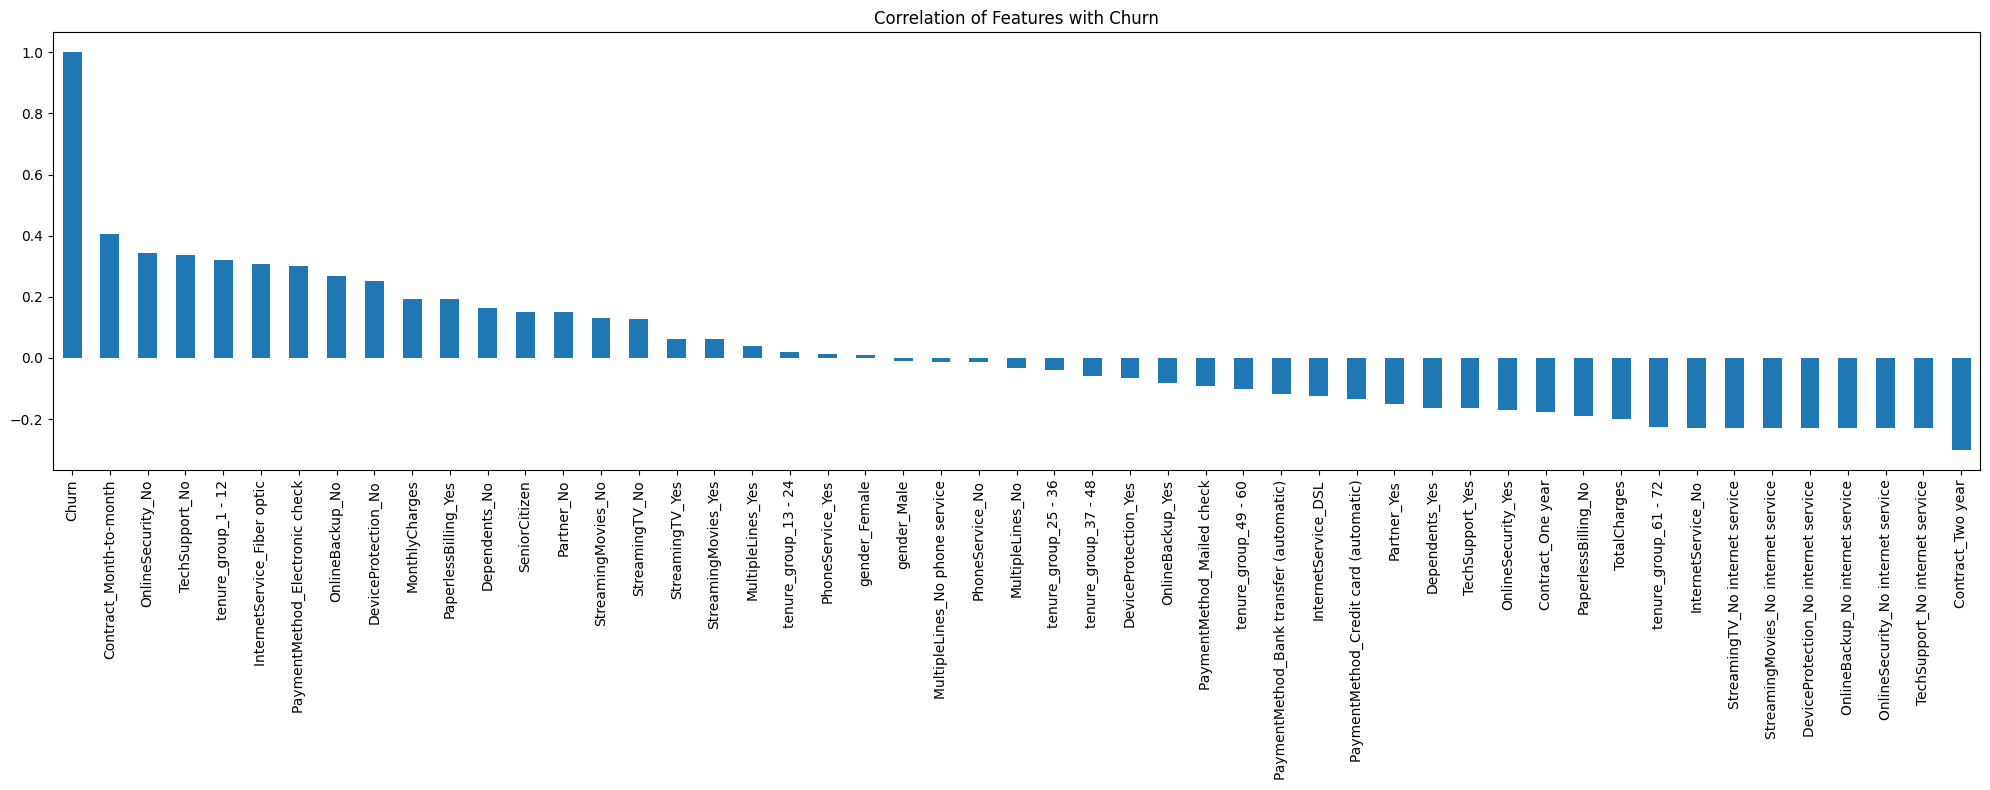

In [43]:
plt.figure(figsize=(20, 8))
new_df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')
plt.title('Correlation of Features with Churn')
plt.tight_layout()
plt.show()



Derived Insights:

HIGH Churn factors:
  - Month-to-month contracts
  - No online security
  - No Tech Support
  - First year of subscription (tenure_group 1-12)
  - Fiber Optic Internet

LOW Churn factors:
  - Long-term contracts (1 or 2 year)
  - No internet service
  - Customers engaged 5+ years

NEGLIGIBLE impact:
  - Gender
  - PhoneService availability
  - Number of multiple lines

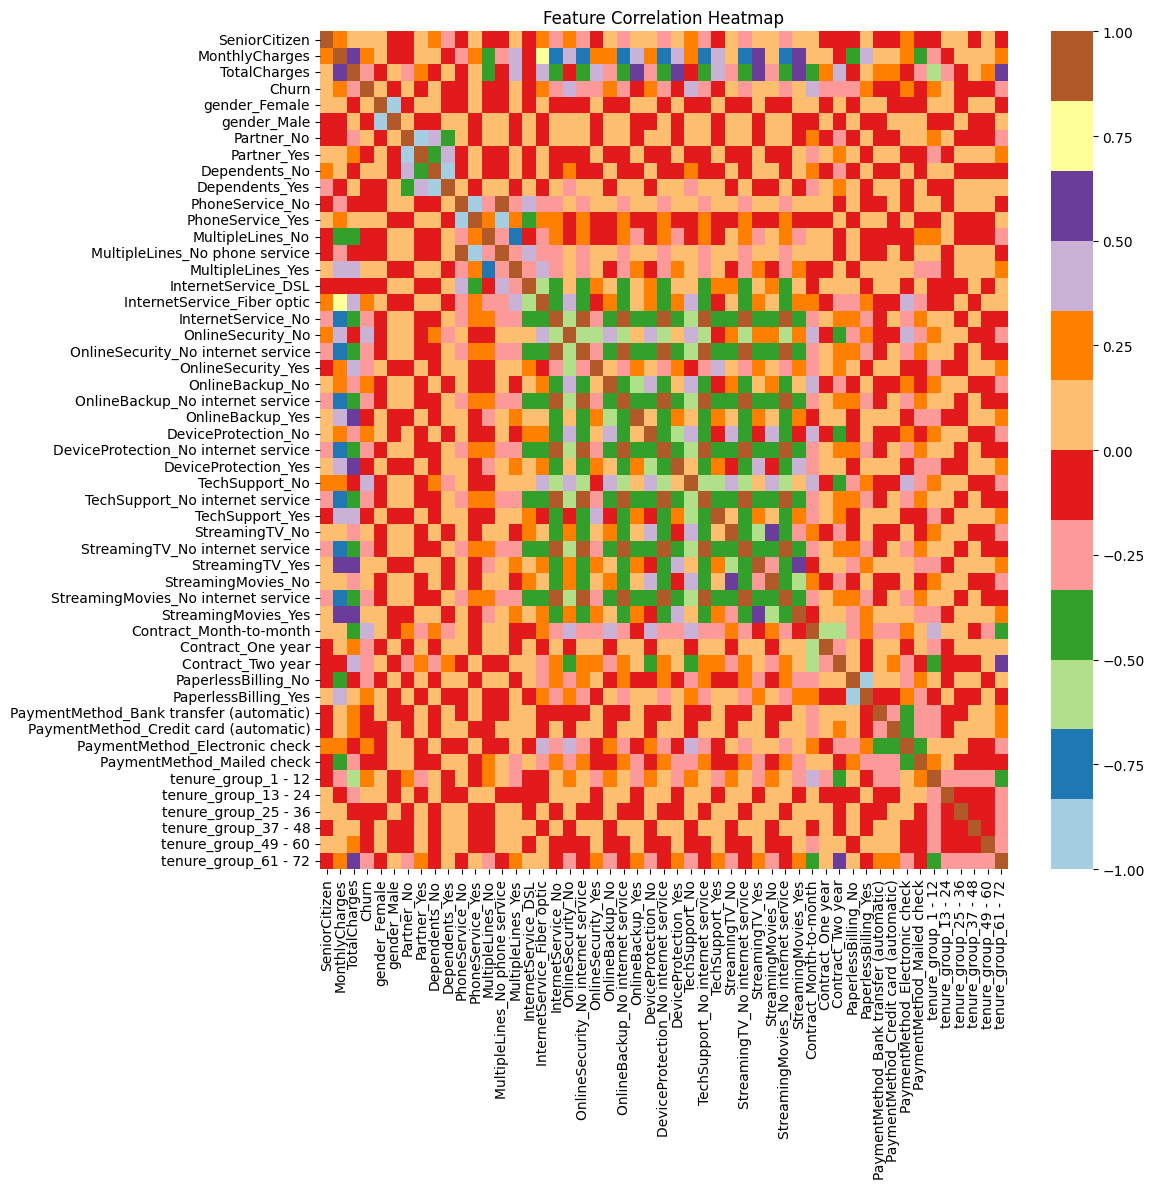

In [44]:
# Heatmap of all feature correlations
plt.figure(figsize=(12, 12))
sns.heatmap(new_df_dummies.corr(), cmap='Paired')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 12. Bivariate Analysis

We compare distributions between churned and non-churned customers using a custom plot function.

In [45]:
# Split into active and churned customer subsets
new_df1_target0 = new_df.loc[new_df['Churn'] == 0]  # Active Customers
new_df1_target1 = new_df.loc[new_df['Churn'] == 1]  # Churned Customers

print("Active customers:", len(new_df1_target0))
print("Churned customers:", len(new_df1_target1))

Active customers: 5163
Churned customers: 1869


In [57]:
def uniplot(df, col, title, hue=None):
    
    sns.set_style('whitegrid')
    sns.set_context('talk')
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['axes.titlepad'] = 30
    
    n_hue_levels = df[hue].nunique() if hue is not None else 1
    fig, ax = plt.subplots()
    width = len(df[col].unique()) + 7 + 4 * n_hue_levels
    fig.set_size_inches(width, 8)
    plt.xticks(rotation=45)
    plt.title(title)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, hue=hue, palette='bright', ax=ax)
    ax.set_yscale('log')
        
    plt.show()

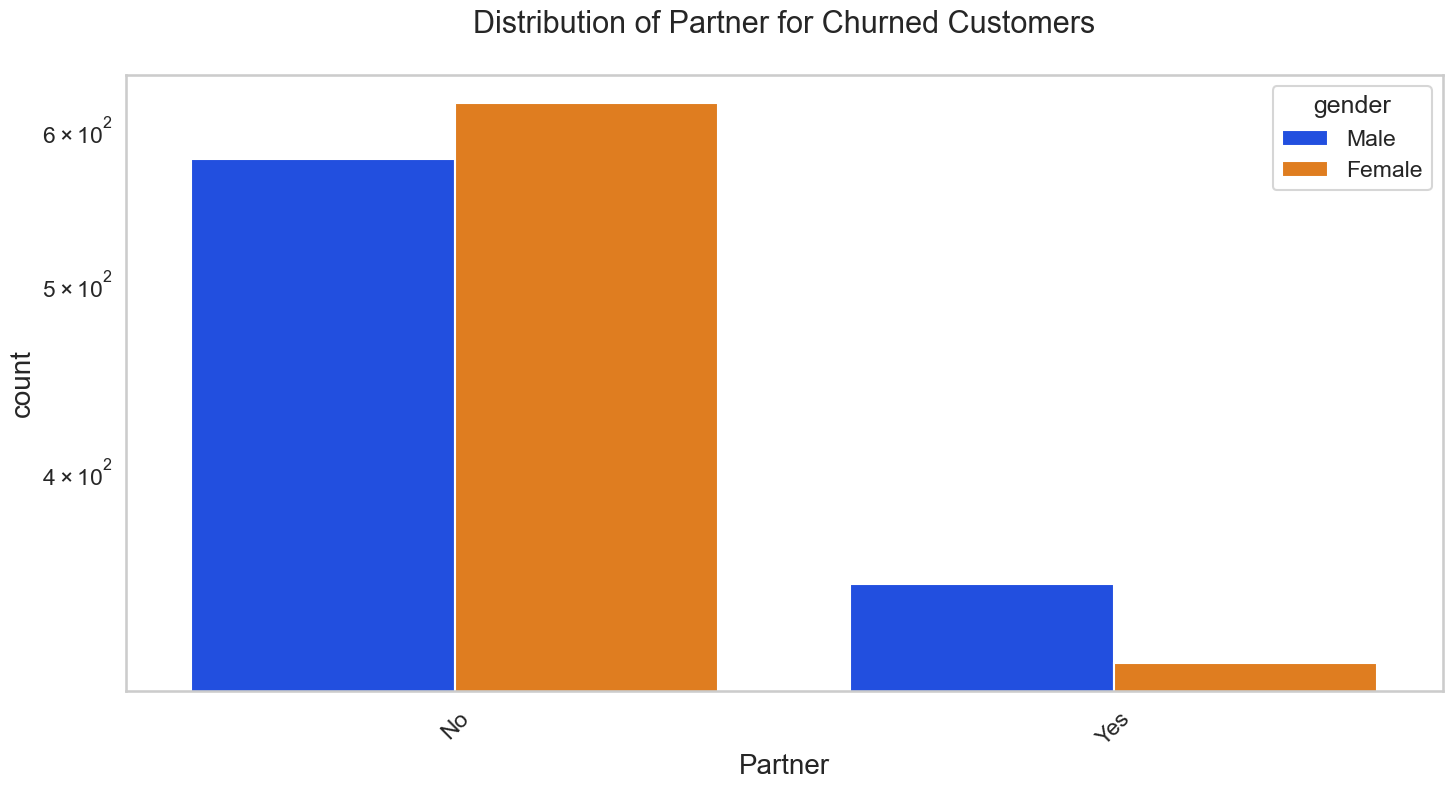

In [58]:
uniplot(new_df1_target1, col='Partner',
        title='Distribution of Partner for Churned Customers', hue='gender')

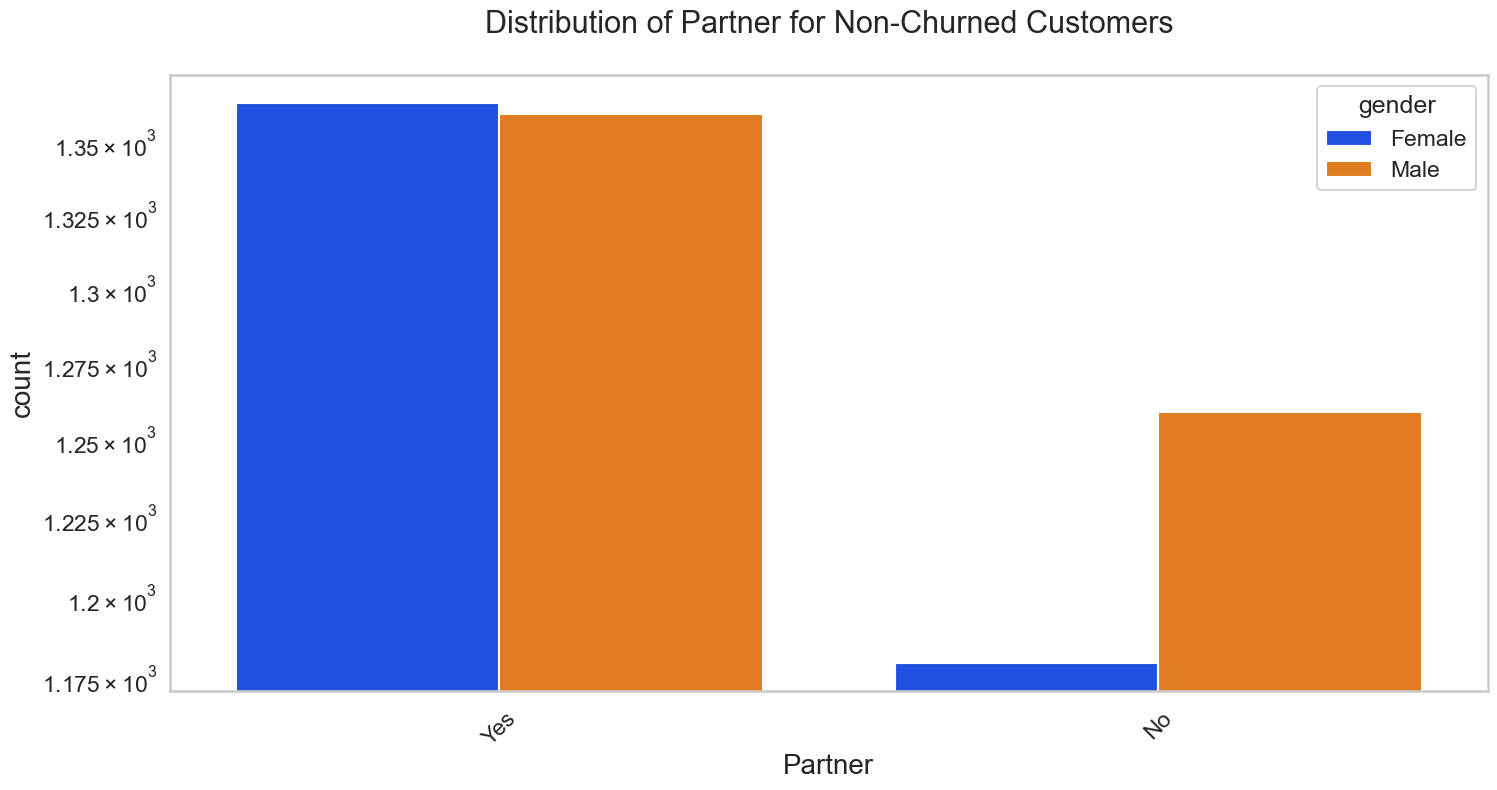

In [59]:
uniplot(new_df1_target0, col='Partner',
        title='Distribution of Partner for Non-Churned Customers', hue='gender')

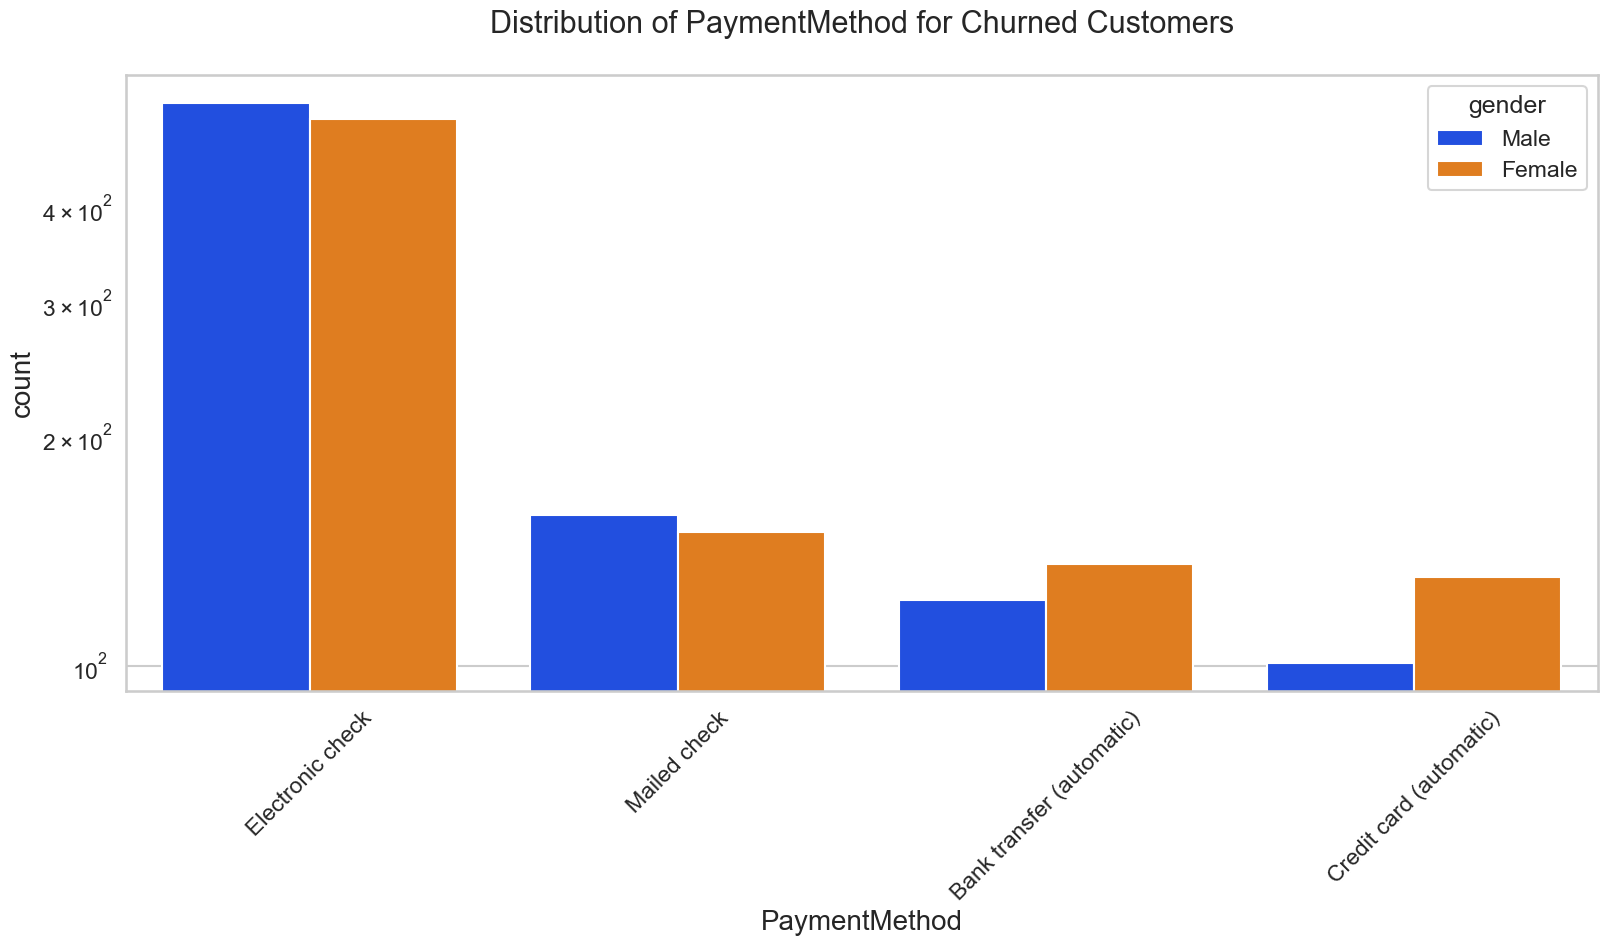

In [60]:
uniplot(new_df1_target1, col='PaymentMethod',
        title='Distribution of PaymentMethod for Churned Customers', hue='gender')

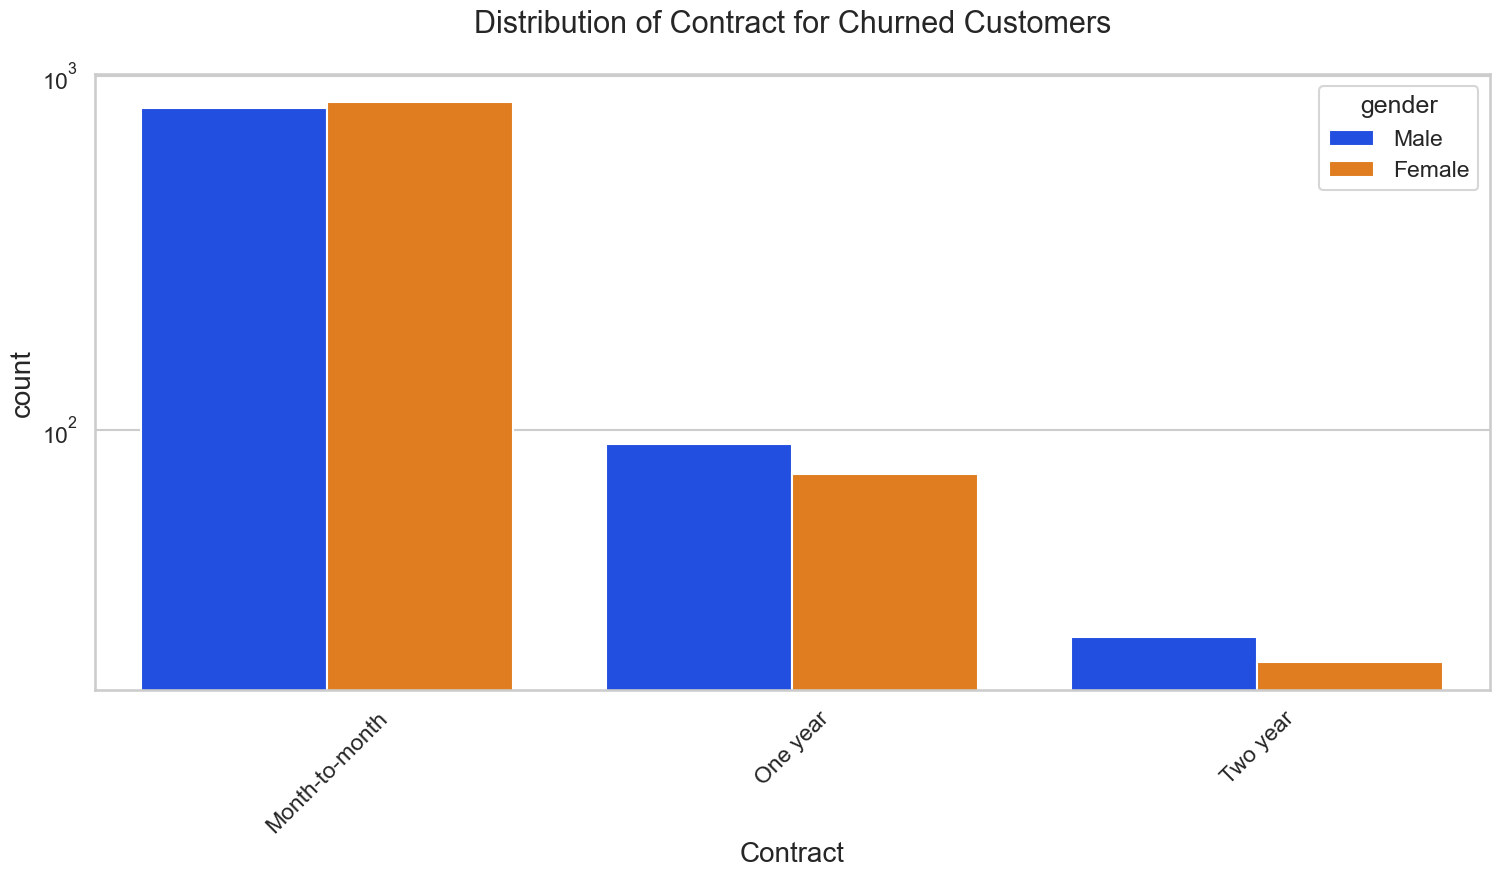

In [61]:
uniplot(new_df1_target1, col='Contract',
        title='Distribution of Contract for Churned Customers', hue='gender')

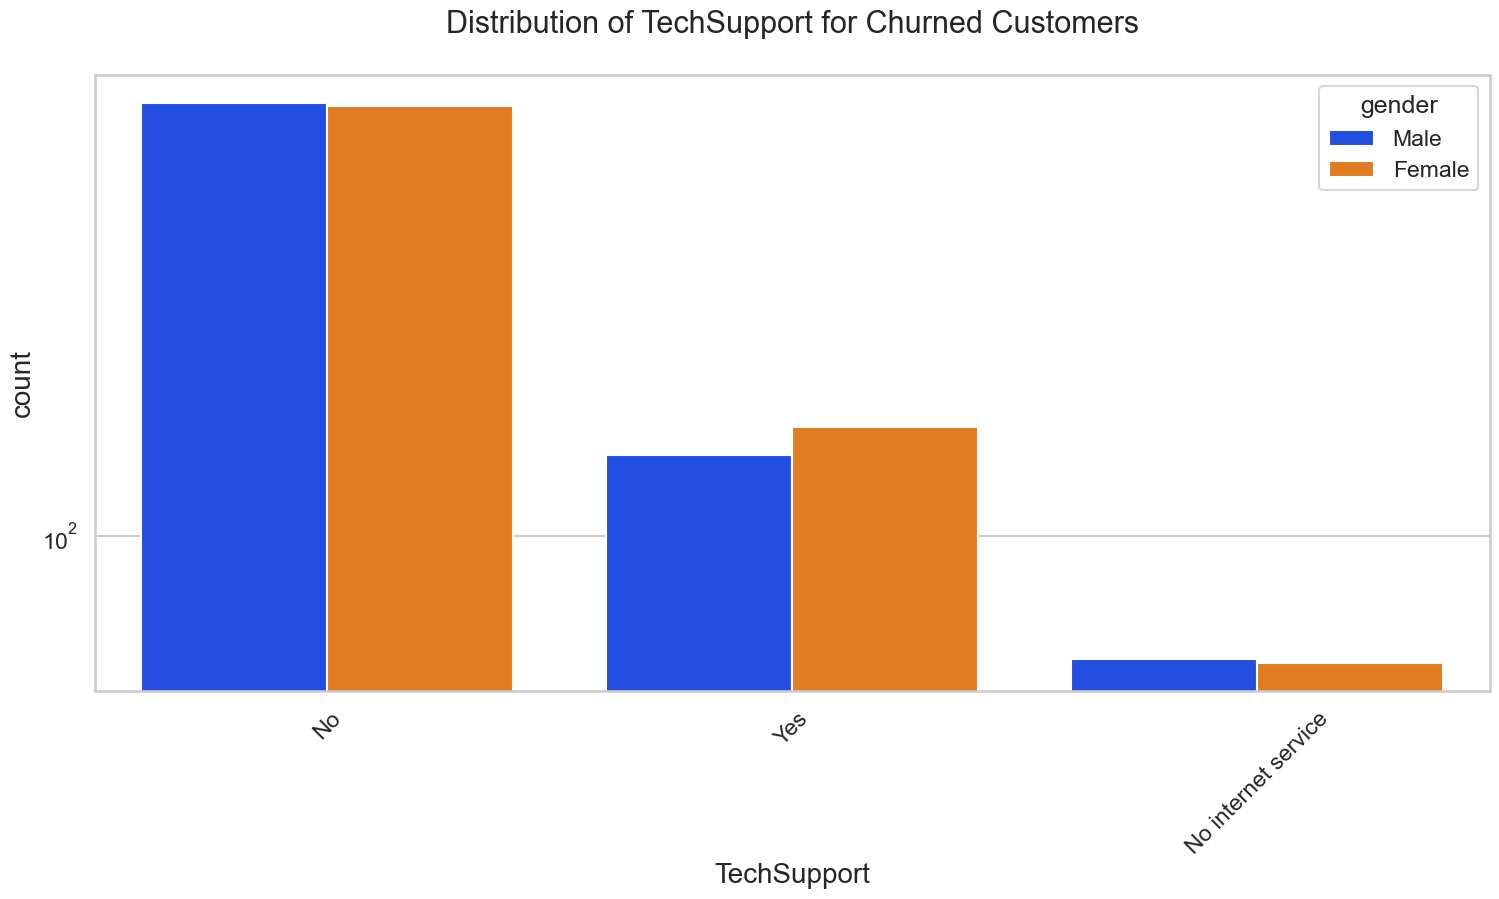

In [62]:
uniplot(new_df1_target1, col='TechSupport',
        title='Distribution of TechSupport for Churned Customers', hue='gender')

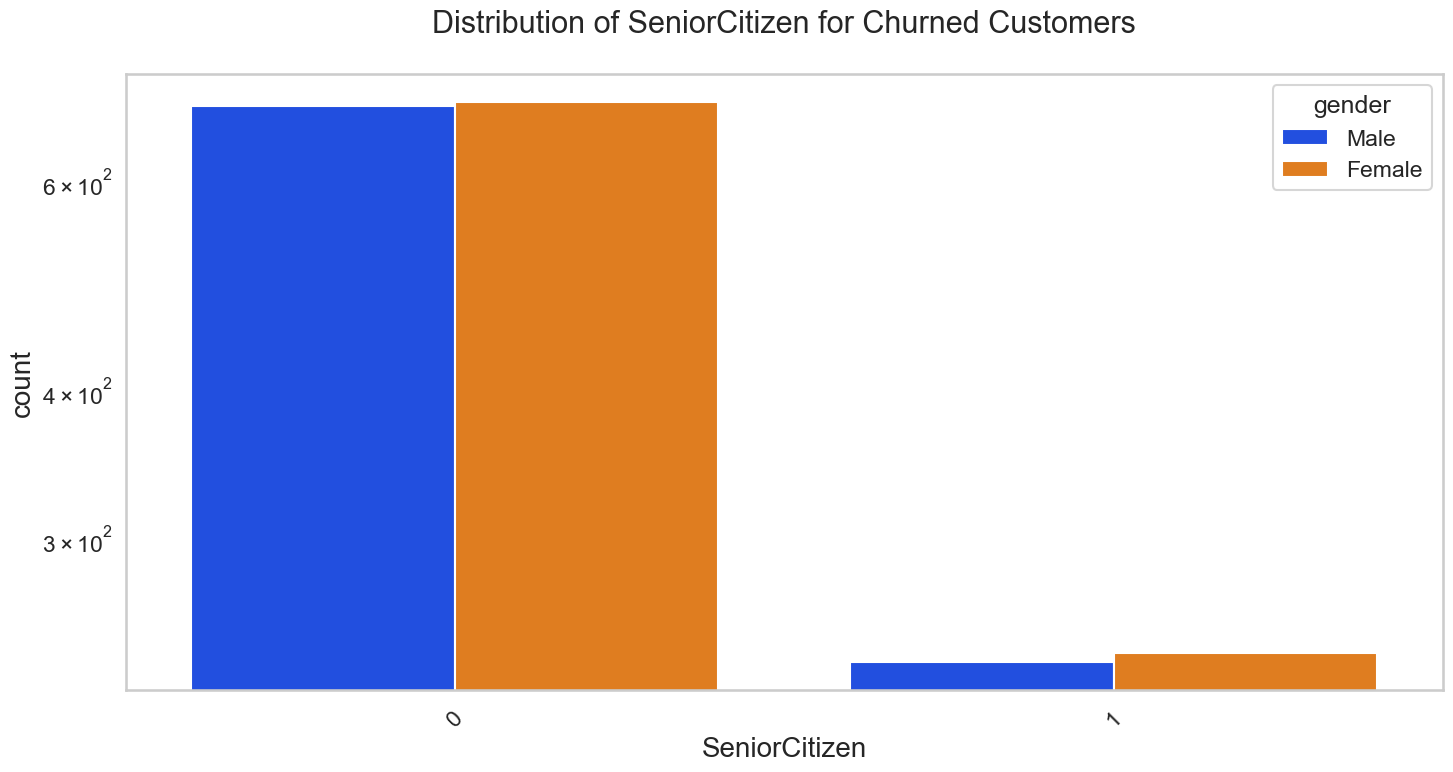

In [63]:
uniplot(new_df1_target1, col='SeniorCitizen',
        title='Distribution of SeniorCitizen for Churned Customers', hue='gender')

## 13. Save Processed Data for Modelling

We save the dummy-encoded dataframe for use in the model building notebook.

In [64]:
OUTPUT_PATH = os.path.join(NOTEBOOK_DIR, 'data', 'tel_churn.csv')
new_df_dummies.to_csv(OUTPUT_PATH, index=False)
print("Saved processed data to:", os.path.abspath(OUTPUT_PATH))

Saved processed data to: c:\projects\Customer_Churn_Prediction\data\tel_churn.csv


## Conclusion

Key insights from this EDA:

1. **Electronic check** payment method customers churn the most.
2. **Month-to-month contract** customers churn at ~41% - no commitment keeps them free to leave.
3. **No Online Security, No Tech Support** categories show high churn.
4. **Non-Senior Citizens** are the majority churners by volume.
5. **Senior Citizens** have a churn rate of ~42% (high relative rate).
6. Customers with **no Partner** churn at ~35%.
7. Customers in tenure group **1-12** are the highest churners - first year is critical.
8. **Higher Monthly Charge + Lower Tenure = Lower Total Charge** -> all three link to high churn.
9. **Females without partners** churn more than male counterparts.
10. **Females using credit card** churn at a higher rate than male credit card users.